# Which of the twenty largest UK urban areas has the deepest band scene?

This is a separate **city-first experiment**. It does not alter the published
notebook. The study begins with the twenty largest UK Functional Urban Areas
(FUAs), curates ten bands for each, measures their current global Spotify
monthly-listener reach, and normalizes the result by FUA population.

The narrative shows the top ten, while every calculation and table retains all
twenty urban areas. Conclusions apply to **the twenty largest UK urban areas**,
not every UK city.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "reference/uk_fua_top20_2024.csv").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repository root containing reference/uk_fua_top20_2024.csv"
    )
SNAPSHOT_ID = "20260718T204000Z"
CATALOG_PATH = ROOT / "data/interim/top20_city_band_catalog_20260901T235027Z.csv"
BAND_METRICS_PATH = ROOT / "data/processed/top20_city_band_metrics_20260718T204000Z.csv"
RANKINGS_PATH = ROOT / "data/processed/top20_city_rankings_20260718T204000Z.csv"
ARTIFACT_DIR = ROOT / "artifacts/top20_city_first/20260718T204000Z"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

catalog = pd.read_csv(CATALOG_PATH, keep_default_na=False)
bands = pd.read_csv(BAND_METRICS_PATH, keep_default_na=False)
rankings = pd.read_csv(RANKINGS_PATH, keep_default_na=False)

assert len(catalog) == 200
assert len(bands) == 200
assert len(rankings) == 20
assert catalog.groupby("study_city_label").size().eq(10).all()
assert catalog["catalogue_review_ready"].all()
assert bands["monthly_listeners"].notna().all()

captured_at = bands["stats_extracted_at_utc"].iloc[0]
display(Markdown(
    f"**Frozen Spotify snapshot:** `{SNAPSHOT_ID}` "
    f"({captured_at}) · **200 bands** · **20 FUAs** · "
    "**10 reviewed bands per FUA**"
))

**Frozen Spotify snapshot:** `20260718T204000Z` (2026-07-18T20:40:00.993779+00:00) · **200 bands** · **20 FUAs** · **10 reviewed bands per FUA**

## 01. Study design and data lineage

Population selection comes first: OECD/EU Functional Urban Areas are ranked
using the OECD's 2024 population observations. This gives one harmonized
geography across England, Scotland, Wales and Northern Ireland.

For each selected FUA, ten bands were manually reviewed for origin and Spotify
identity. Places within the wider FUA, such as Abingdon for Oxford or Stockton
for Middlesbrough, can count when their FUA membership is part of the reviewed
mapping.

Spotify values are a dated snapshot from Spotify's read-only web-player artist
overview. That endpoint is undocumented, so the raw responses are retained and
the notebook itself performs no network calls.

In [2]:
lineage = pd.DataFrame(
    [
        {
            "stage": "Urban-area universe",
            "frozen input": "reference/uk_fua_top20_2024.csv",
            "definition": "Top 20 UK OECD/EU Functional Urban Areas",
        },
        {
            "stage": "Band catalogue",
            "frozen input": str(CATALOG_PATH.relative_to(ROOT)),
            "definition": "10 origin- and identity-reviewed bands per FUA",
        },
        {
            "stage": "Reach snapshot",
            "frozen input": str(BAND_METRICS_PATH.relative_to(ROOT)),
            "definition": "Spotify global monthly listeners at one UTC capture",
        },
        {
            "stage": "Ranking output",
            "frozen input": str(RANKINGS_PATH.relative_to(ROOT)),
            "definition": "Untrimmed and symmetric 10% per-tail results",
        },
    ]
)
display(lineage.style.hide(axis="index"))

stage,frozen input,definition
Urban-area universe,reference/uk_fua_top20_2024.csv,Top 20 UK OECD/EU Functional Urban Areas
Band catalogue,data/interim/top20_city_band_catalog_20260901T235027Z.csv,10 origin- and identity-reviewed bands per FUA
Reach snapshot,data/processed/top20_city_band_metrics_20260718T204000Z.csv,Spotify global monthly listeners at one UTC capture
Ranking output,data/processed/top20_city_rankings_20260718T204000Z.csv,Untrimmed and symmetric 10% per-tail results


## 02. The population-selected universe

The population column below is the denominator used by the study. All twenty
areas remain visible here even though later narrative charts show the top ten.

In [3]:
universe = (
    catalog[
        [
            "uk_population_rank",
            "study_city_label",
            "official_fua_name",
            "population",
            "population_year",
            "fua_code",
        ]
    ]
    .drop_duplicates()
    .sort_values("uk_population_rank")
)
display(
    universe.style
    .hide(axis="index")
    .format({"population": "{:,.0f}", "population_year": "{:.0f}"})
)

uk_population_rank,study_city_label,official_fua_name,population,population_year,fua_code
1,London,London,"12,666,099",2024,UK001F
2,Manchester,Manchester,"3,595,966",2024,UK008F
3,Birmingham,West Midlands urban area,"3,247,941",2024,UK002F
4,Leeds,Leeds,"3,070,506",2024,UK003F
5,Glasgow,Glasgow,"1,895,840",2024,UK004F
6,Liverpool,Liverpool,"1,597,536",2024,UK006F
7,Newcastle,Newcastle upon Tyne,"1,221,203",2024,UK013F
8,Sheffield,Sheffield,"1,217,504",2024,UK010F
9,Bristol,Bristol,"1,025,309",2024,UK011F
10,Leicester,Leicester,"967,988",2024,UK014F


## 03. Baseline: all ten selected bands

The baseline adds the ten bands' monthly listeners and divides that total by
FUA population. This measures selected global Spotify reach per resident; it
does not measure local listening.

In [4]:
baseline = rankings.sort_values("untrimmed_rank").copy()
baseline_table = baseline[
    [
        "untrimmed_rank",
        "city",
        "population",
        "untrimmed_value",
        "untrimmed_listeners_per_million_residents",
        "highest_excluded_bands",
        "top_band_concentration",
    ]
].rename(
    columns={
        "untrimmed_rank": "rank",
        "city": "urban area",
        "untrimmed_value": "ten-band listeners",
        "untrimmed_listeners_per_million_residents": "listeners per million residents",
        "highest_excluded_bands": "largest selected band",
        "top_band_concentration": "largest-band share",
    }
)
display(
    baseline_table.style
    .hide(axis="index")
    .format(
        {
            "population": "{:,.0f}",
            "ten-band listeners": "{:,.0f}",
            "listeners per million residents": "{:,.0f}",
            "largest-band share": "{:.1%}",
        }
    )
)

rank,urban area,population,ten-band listeners,listeners per million residents,largest selected band,largest-band share
1,Oxford,"606,748","79,630,555","131,241,562",Radiohead,54.2%
2,Sheffield,"1,217,504","93,656,067","76,924,648",Arctic Monkeys,55.8%
3,Liverpool,"1,597,536","71,892,005","45,001,806",The Beatles,52.8%
4,Manchester,"3,595,966","138,676,765","38,564,537",Oasis,28.6%
5,London,"12,666,099","366,760,605","28,956,082",Coldplay,25.1%
6,Birmingham,"3,247,941","83,758,431","25,788,163",ELO,21.9%
7,Glasgow,"1,895,840","44,115,424","23,269,592",Franz Ferdinand,24.5%
8,Belfast,"817,574","15,253,374","18,656,873",Two Door Cinema Club,64.8%
9,Bristol,"1,025,309","17,389,817","16,960,562",Massive Attack,50.0%
10,Newcastle,"1,221,203","16,201,200","13,266,590",The Animals,76.1%


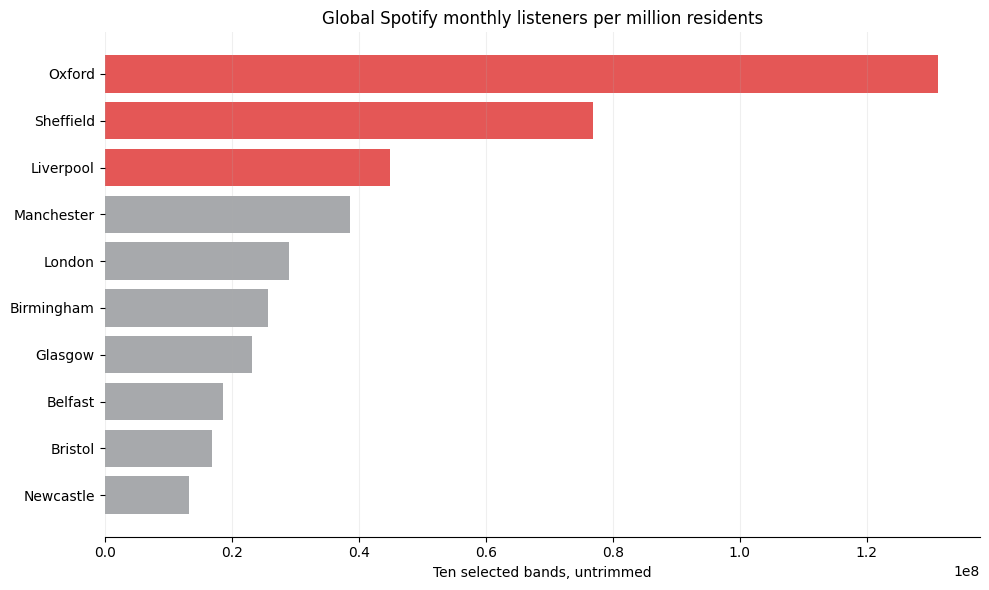

artifacts/top20_city_first/20260718T204000Z/01_untrimmed_top10.png


In [5]:
top10 = baseline.head(10).sort_values(
    "untrimmed_listeners_per_million_residents"
)
top3 = set(baseline.head(3)["city"])
colors = ["#e45756" if city in top3 else "#a7a9ac" for city in top10["city"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top10["city"],
    top10["untrimmed_listeners_per_million_residents"],
    color=colors,
)
ax.set_title("Global Spotify monthly listeners per million residents")
ax.set_xlabel("Ten selected bands, untrimmed")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
chart_path = ARTIFACT_DIR / "01_untrimmed_top10.png"
fig.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print(chart_path.relative_to(ROOT))

## 04. Scene-depth test: remove one band from each tail

For each FUA, the highest- and lowest-listener band are removed. The remaining
eight bands form a **10% trimmed mean at each tail** (20% removed in total).
That mean is divided by population, yielding the
**population-normalized trimmed mean**.

Because every FUA retains exactly eight bands, ranking the normalized trimmed
mean is identical to ranking the normalized trimmed total. The mean is kept
because it is the clearest description of the estimator.

In [6]:
trimmed = rankings.sort_values("rank").copy()
trimmed_table = trimmed[
    [
        "rank",
        "city",
        "population_normalized_trimmed_mean_per_million",
        "highest_excluded_bands",
        "lowest_excluded_bands",
        "untrimmed_rank",
        "rank_shift_after_trim",
    ]
].rename(
    columns={
        "city": "urban area",
        "population_normalized_trimmed_mean_per_million": (
            "trimmed mean per million residents"
        ),
        "highest_excluded_bands": "highest removed",
        "lowest_excluded_bands": "lowest removed",
        "untrimmed_rank": "baseline rank",
        "rank_shift_after_trim": "rank improvement",
    }
)
display(
    trimmed_table.style
    .hide(axis="index")
    .format({"trimmed mean per million residents": "{:,.0f}"})
)

rank,urban area,trimmed mean per million residents,highest removed,lowest removed,baseline rank,rank improvement
1,Oxford,"7,511,445",Radiohead,The Candyskins,1,0
2,Sheffield,"4,140,427",Arctic Monkeys,Ace,2,0
3,Manchester,"3,320,109",Oasis,The Stone Roses,4,1
4,London,"2,572,978",Coldplay,Blur,5,1
5,Liverpool,"2,484,623",The Beatles,Echo & the Bunnymen,3,-2
6,Birmingham,"2,470,251",ELO,Editors,6,0
7,Glasgow,"2,120,860",Franz Ferdinand,Belle and Sebastian,7,0
8,Bristol,"1,060,239",Massive Attack,Roni Size / Reprazent,9,1
9,Belfast,"820,800",Two Door Cinema Club,New Pagans,8,-1
10,Leeds,"791,629",Alt-J,The Wedding Present,12,2


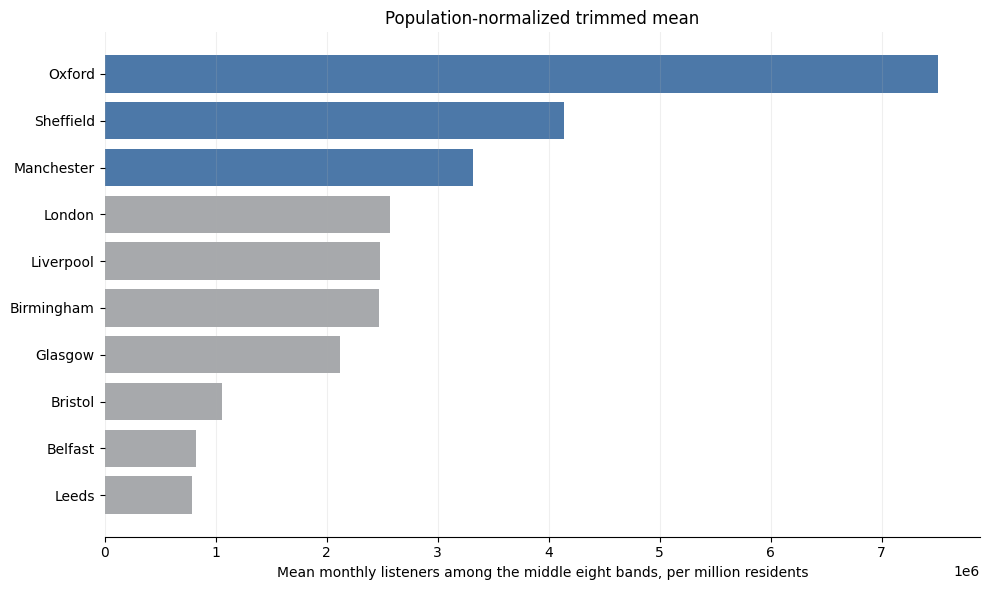

artifacts/top20_city_first/20260718T204000Z/02_trimmed_top10.png


In [7]:
top10_trimmed = trimmed.head(10).sort_values(
    "population_normalized_trimmed_mean_per_million"
)
top3_trimmed = set(trimmed.head(3)["city"])
colors = [
    "#4c78a8" if city in top3_trimmed else "#a7a9ac"
    for city in top10_trimmed["city"]
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top10_trimmed["city"],
    top10_trimmed["population_normalized_trimmed_mean_per_million"],
    color=colors,
)
ax.set_title("Population-normalized trimmed mean")
ax.set_xlabel("Mean monthly listeners among the middle eight bands, per million residents")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
chart_path = ARTIFACT_DIR / "02_trimmed_top10.png"
fig.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print(chart_path.relative_to(ROOT))

## 05. What changes after trimming?

Rank movement distinguishes a scene supported by several acts from one whose
baseline is especially dependent on a single giant band.

In [8]:
comparison = rankings[
    [
        "city",
        "untrimmed_rank",
        "rank",
        "rank_shift_after_trim",
        "highest_excluded_bands",
        "top_band_concentration",
    ]
].sort_values(["rank", "city"]).rename(
    columns={
        "city": "urban area",
        "untrimmed_rank": "baseline rank",
        "rank": "trimmed rank",
        "rank_shift_after_trim": "rank improvement",
        "highest_excluded_bands": "highest removed",
        "top_band_concentration": "largest-band share",
    }
)
rank_correlation = rankings["untrimmed_rank"].corr(rankings["rank"])
display(Markdown(f"**Baseline–trimmed rank correlation: {rank_correlation:.3f}.**"))
display(
    comparison.style
    .hide(axis="index")
    .format({"largest-band share": "{:.1%}"})
)

**Baseline–trimmed rank correlation: 0.976.**

urban area,baseline rank,trimmed rank,rank improvement,highest removed,largest-band share
Oxford,1,1,0,Radiohead,54.2%
Sheffield,2,2,0,Arctic Monkeys,55.8%
Manchester,4,3,1,Oasis,28.6%
London,5,4,1,Coldplay,25.1%
Liverpool,3,5,-2,The Beatles,52.8%
Birmingham,6,6,0,ELO,21.9%
Glasgow,7,7,0,Franz Ferdinand,24.5%
Bristol,9,8,1,Massive Attack,50.0%
Belfast,8,9,-1,Two Door Cinema Club,64.8%
Leeds,12,10,2,Alt-J,29.4%


## 06. Reading the result

- Oxford ranks first in both specifications. Radiohead accounts for a
  large share of the ten-band total, but Oxford still leads after Radiohead
  and its smallest selected band are removed. The middle of Oxford's catalogue
  still supports the result after its largest act is removed.
- Sheffield remains second. Removing Arctic Monkeys does not erase the
  strength of its other selected bands.
- Manchester moves from fourth to third, while Liverpool drops from
  third to fifth after the highest and lowest bands are removed.
- The overall rank correlation is high, so trimming changes the interpretation
  of a few highly concentrated cities more than it changes the whole ordering.

## 07. Audit the selected bands

This table retains the full 200-band catalogue, origin evidence, Spotify
identity and current metric. It is deliberately long: the narrative can show
ten results without hiding the study's complete selection.

In [9]:
audit = bands[
    [
        "uk_population_rank",
        "study_city_label",
        "band_name",
        "claimed_formation_place",
        "origin_review_status",
        "origin_evidence_url",
        "spotify_id",
        "spotify_name",
        "monthly_listeners",
    ]
].sort_values(["uk_population_rank", "monthly_listeners"], ascending=[True, False])
display(
    audit.style
    .hide(axis="index")
    .format({"monthly_listeners": "{:,.0f}"})
)

uk_population_rank,study_city_label,band_name,claimed_formation_place,origin_review_status,origin_evidence_url,spotify_id,spotify_name,monthly_listeners
1,London,Coldplay,London,reviewed,https://musicbrainz.org/artist/cc197bad-dc9c-440d-a5b5-d52ba2e14234,4gzpq5DPGxSnKTe4SA8HAU,Coldplay,"92,034,104"
1,London,Queen,London,reviewed,https://musicbrainz.org/artist/0383dadf-2a4e-4d10-a46a-e9e041da8eb3,1dfeR4HaWDbWqFHLkxsg1d,Queen,"51,601,234"
1,London,Fleetwood Mac,London,reviewed,https://musicbrainz.org/artist/bd13909f-1c29-4c27-a874-d4aaf27c5b1a,08GQAI4eElDnROBrJRGE0X,Fleetwood Mac,"50,959,935"
1,London,The Police,London,reviewed,https://musicbrainz.org/artist/9e0e2b01-41db-4008-bd8b-988977d6019a,5NGO30tJxFlKixkPSgXcFE,The Police,"39,887,109"
1,London,The Rolling Stones,London,reviewed,https://musicbrainz.org/artist/b071f9fa-14b0-4217-8e97-eb41da73f598,22bE4uQ6baNwSHPVcDxLCe,The Rolling Stones,"30,690,194"
1,London,Pink Floyd,London,reviewed,https://musicbrainz.org/artist/83d91898-7763-47d7-b03b-b92132375c47,0k17h0D3J5VfsdmQ1iZtE9,Pink Floyd,"26,546,155"
1,London,Florence and the Machine,London,reviewed,https://musicbrainz.org/artist/5fee3020-513b-48c2-b1f7-4681b01db0c6,1moxjboGR7GNWYIMWsRjgG,Florence + The Machine,"25,836,943"
1,London,Led Zeppelin,London,reviewed,https://musicbrainz.org/artist/678d88b2-87b0-403b-b63d-5da7465aecc3,36QJpDe2go2KgaRleHCDTp,Led Zeppelin,"20,605,707"
1,London,The Clash,London,reviewed,https://musicbrainz.org/artist/8f92558c-2baa-4758-8c38-615519e9deda,3RGLhK1IP9jnYFH4BRFJBS,The Clash,"14,589,467"
1,London,Blur,London,reviewed,https://musicbrainz.org/artist/ba853904-ae25-4ebb-89d6-c44cfbd71bd2,7MhMgCo0Bl0Kukl93PZbYS,Blur,"14,009,757"


## 08. Limitations and publication status

This completed experiment is reproducible from frozen local files, but it
remains an exploratory ranking:

- Ten manually curated bands are not a census of each area's music.
- The catalogue excludes solo artists and can reflect genre and documentation
  bias, especially in the smaller scenes.
- Some acts are assigned through the wider Functional Urban Area rather than
  the named core city. Those mappings are reviewed but not generated from an
  automated OECD municipality correspondence table.
- Monthly listeners are a volatile 28-day reach measure, not historical
  influence, sales, local audience, quality or cultural importance.
- Spotify's web-player endpoint is undocumented. The raw response snapshot is
  retained, but future refreshes may require a different collector.
- A symmetric trim reduces sensitivity to both a blockbuster and a tiny act,
  but it does not remove catalogue-selection bias.

The result applies to **the selected bands
from the twenty largest UK urban areas at this snapshot**, not to every band,
every city, or UK music history as a whole.

In [10]:
assert set(baseline["city"]) == set(trimmed["city"])
assert rankings["input_bands"].eq(10).all()
assert rankings["retained_bands"].eq(8).all()
assert rankings["trim_fraction_each_tail"].eq(0.1).all()
assert rankings["population_normalized_trimmed_mean"].notna().all()
print("Validation passed: frozen 20-city analysis is complete and internally balanced.")

Validation passed: frozen 20-city analysis is complete and internally balanced.
